In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('amazon_2024_valentines_best_sellers.csv')

In [ ]:
df

,title,brand,description,starsBreakdown/3star,starsBreakdown/4star,starsBreakdown/5star,reviewsCount,price,price/currency,price/value,categoryPageData/productPosition
0,"Ferrero Rocher, 24 Count, Premium Milk Chocola...",Ferrero Rocher,Ferrero Rocher's milk chocolate gift box offer...,0.02,0.07,0.89,20021.0,NaN,$,11.39,7
1,"HERSHEY'S NUGGETS Assorted Chocolate, Valentin...",HERSHEY'S,This HERSHEY'S NUGGETS candy assortment is fil...,0.03,0.10,0.84,18891.0,NaN,$,10.69,16
2,LEGO Icons Flower Bouquet Building Decoration ...,LEGO,Giving and receiving beautiful flowers is such...,0.01,0.05,0.92,19395.0,NaN,$,47.99,2
3,BodyRefresh Shower Steamers Aromatherapy - 8 P...,BodyRefresh,NaN,0.07,0.15,0.67,593.0,NaN,$,9.99,10
4,JoJowell Shower Steamers Aromatherapy - 21Pcs ...,JoJowell,NaN,0.10,0.15,0.63,816.0,NaN,$,21.99,11
...,...,...,...,...,...,...,...,...,...,...,...
213,JOYIN 28 Packs Valentine's Day Gift Cards with...,JOYIN,NaN,0.14,0.17,0.55,30.0,NaN,$,22.99,305
214,THEMEROL Natural Gemstone Bracelet Gifts for D...,THEMEROL,NaN,0.03,0.07,0.87,140.0,NaN,NaN,NaN,300
215,Juegoal 28 Pack Valentines Day Gift Cards for ...,Juegoal,NaN,0.05,0.16,0.68,113.0,NaN,$,21.99,296
216,Double Couple Gift for Mom Women-Rose Cute Bea...,Double Couple,NaN,0.06,0.15,0.72,347.0,NaN,$,19.59,298


In [ ]:
# Display basic information about the dataset
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   title                             218 non-null    object 
 1   brand                             217 non-null    object 
 2   description                       46 non-null     object 
 3   starsBreakdown/3star              218 non-null    float64
 4   starsBreakdown/4star              218 non-null    float64
 5   starsBreakdown/5star              218 non-null    float64
 6   reviewsCount                      216 non-null    float64
 7   price                             0 non-null      float64
 8   price/currency                    169 non-null    object 
 9   price/value                       169 non-null    float64
 10  categoryPageData/productPosition  218 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 18.9+ KB


(None,
                                                title           brand  \
 0  Ferrero Rocher, 24 Count, Premium Milk Chocola...  Ferrero Rocher   
 1  HERSHEY'S NUGGETS Assorted Chocolate, Valentin...       HERSHEY'S   
 2  LEGO Icons Flower Bouquet Building Decoration ...            LEGO   
 3  BodyRefresh Shower Steamers Aromatherapy - 8 P...     BodyRefresh   
 4  JoJowell Shower Steamers Aromatherapy - 21Pcs ...        JoJowell   
 
                                          description  starsBreakdown/3star  \
 0  Ferrero Rocher's milk chocolate gift box offer...                  0.02   
 1  This HERSHEY'S NUGGETS candy assortment is fil...                  0.03   
 2  Giving and receiving beautiful flowers is such...                  0.01   
 3                                                NaN                  0.07   
 4                                                NaN                  0.10   
 
    starsBreakdown/4star  starsBreakdown/5star  reviewsCount  price  \
 0    

In [ ]:
# Drop the fully missing 'price' column and handle other missing values
df.drop(columns=['price'], inplace=True)

# Fill missing 'brand' with 'Unknown' and 'reviewsCount' with 0 (assuming no reviews)
df['brand'].fillna('Unknown', inplace=True)
df['reviewsCount'].fillna(0, inplace=True)

# Check if there's any other missing data
missing_data = df.isnull().sum()

# Descriptive statistics for numerical columns
desc_stats = df.describe()

missing_data, desc_stats


<ipython-input-7-6f695d66fd2f>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['brand'].fillna('Unknown', inplace=True)
<ipython-input-7-6f695d66fd2f>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.m

(title                                 0
 brand                                 0
 description                         172
 starsBreakdown/3star                  0
 starsBreakdown/4star                  0
 starsBreakdown/5star                  0
 reviewsCount                          0
 price/currency                       49
 price/value                          49
 categoryPageData/productPosition      0
 dtype: int64,
        starsBreakdown/3star  starsBreakdown/4star  starsBreakdown/5star  \
 count            218.000000            218.000000            218.000000   
 mean               0.049220              0.105275              0.767936   
 std                0.041966              0.066756              0.151997   
 min                0.000000              0.000000              0.000000   
 25%                0.030000              0.072500              0.720000   
 50%                0.040000              0.100000              0.790000   
 75%                0.070000              0

<ipython-input-8-db51d0da943b>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_reviews, x='reviewsCount', y='title', palette='viridis')
<ipython-input-8-db51d0da943b>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette='coolwarm')
<ipython-input-8-db51d0da943b>:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


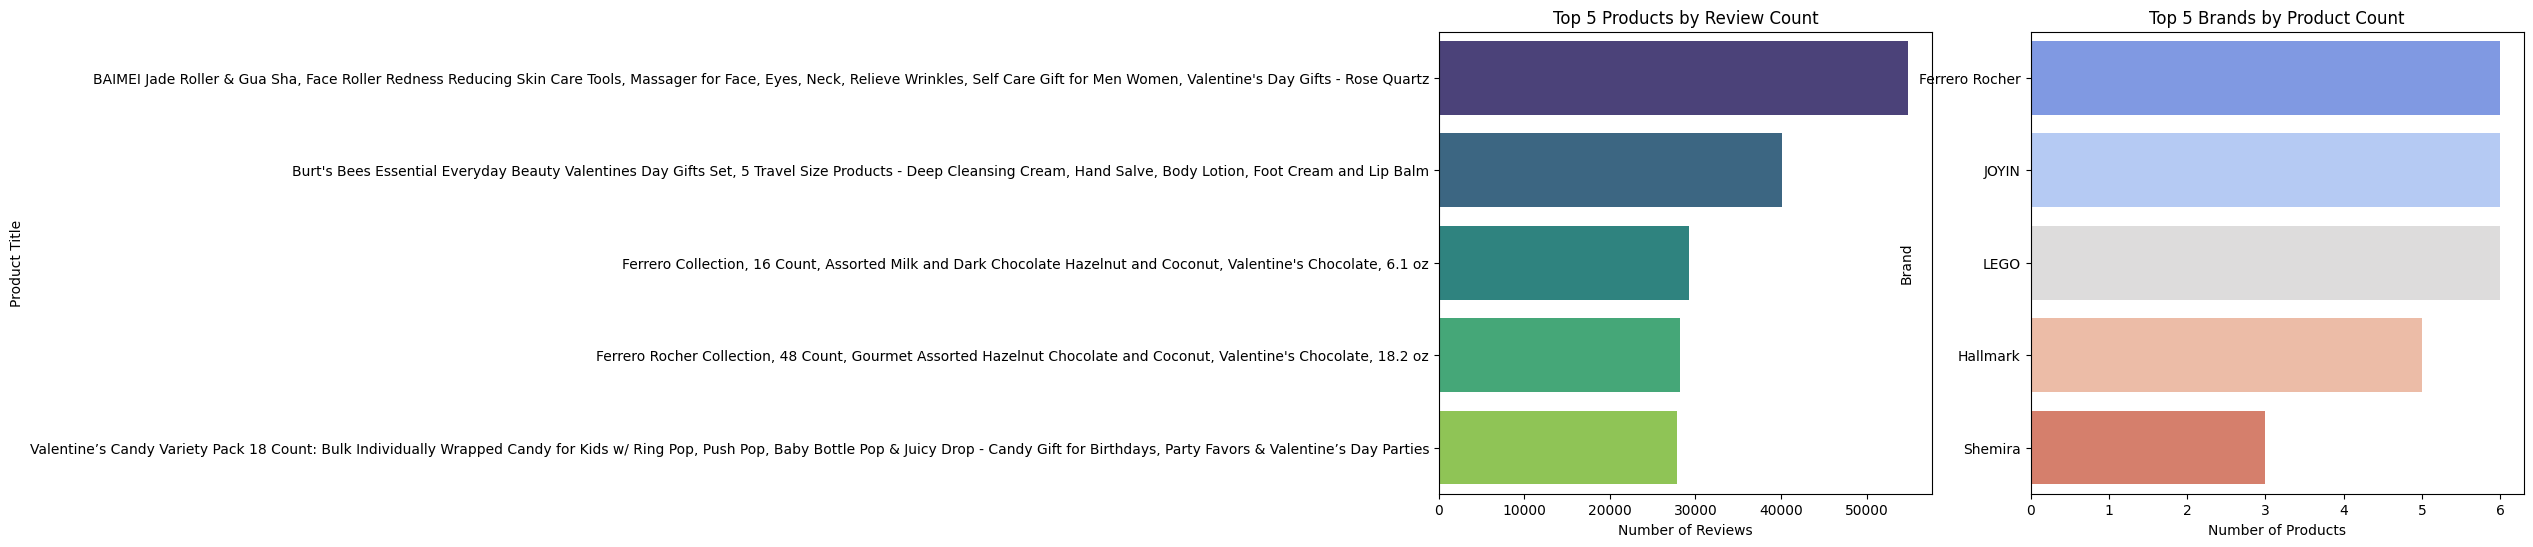

(None, 0.04505130838036896)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 5 products by reviews count
top_reviews = df.sort_values(by='reviewsCount', ascending=False).head(5)[['title', 'brand', 'reviewsCount', 'starsBreakdown/5star']]

# Average price vs average reviews
price_reviews_corr = df[['price/value', 'reviewsCount']].corr().iloc[0, 1]

# Top brands by number of products listed
top_brands = df['brand'].value_counts().head(5)

# Plotting
plt.figure(figsize=(14, 6))

# Top products by reviews
plt.subplot(1, 2, 1)
sns.barplot(data=top_reviews, x='reviewsCount', y='title', palette='viridis')
plt.title('Top 5 Products by Review Count')
plt.xlabel('Number of Reviews')
plt.ylabel('Product Title')

# Top brands by product count
plt.subplot(1, 2, 2)
sns.barplot(x=top_brands.values, y=top_brands.index, palette='coolwarm')
plt.title('Top 5 Brands by Product Count')
plt.xlabel('Number of Products')
plt.ylabel('Brand')

plt.tight_layout()
plt.show(), price_reviews_corr
